<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Cristian Jara
- Nombre de alumno 2: Felipe Fierro


### **Link de repositorio de GitHub:** [https://github.com/cristianjaram/MDS7202-labs.git](https://github.com/cristianjaram/MDS7202-labs.git)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [2]:
# Inserte su código aquí

# Librerías necesarias
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

# Vista general
print(df.shape)
print(df.info())
print(df.describe())

# =========================
# EXPLORACIÓN Y TRANSFORMACIONES
# =========================

# Revisar si hay valores nulos
print(df.isnull().sum())

# En este dataset, la mayoría de las variables son numéricas (incluso si son binarias o categóricas codificadas con 0/1)
# El modelo XGBoost NO requiere escalado para variables de tipo árbol.
# Sin embargo, variables continuas como BMI, GenHlth, MentHlth, PhysHlth pueden tener escalas diferentes.

# En general, XGBoost no se ve afectado por escalado, pero si queremos estandarizar para futuras comparaciones,
# podríamos aplicar un StandardScaler solo a las variables continuas.
continuous_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth']

# =========================
# DIVISIÓN EN TRAIN/TEST
# =========================

X = df.drop(columns='Diabetes')
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

# =========================
# PREPROCESAMIENTO
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), continuous_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

# =========================
# PIPELINE + MODELO XGBOOST
# =========================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# =========================
# EVALUACIÓN
# =========================

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


(70692, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke 

c:\Users\Felipe\Desktop\Lab MDS\lab_venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:45:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74     11782
         1.0       0.73      0.80      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

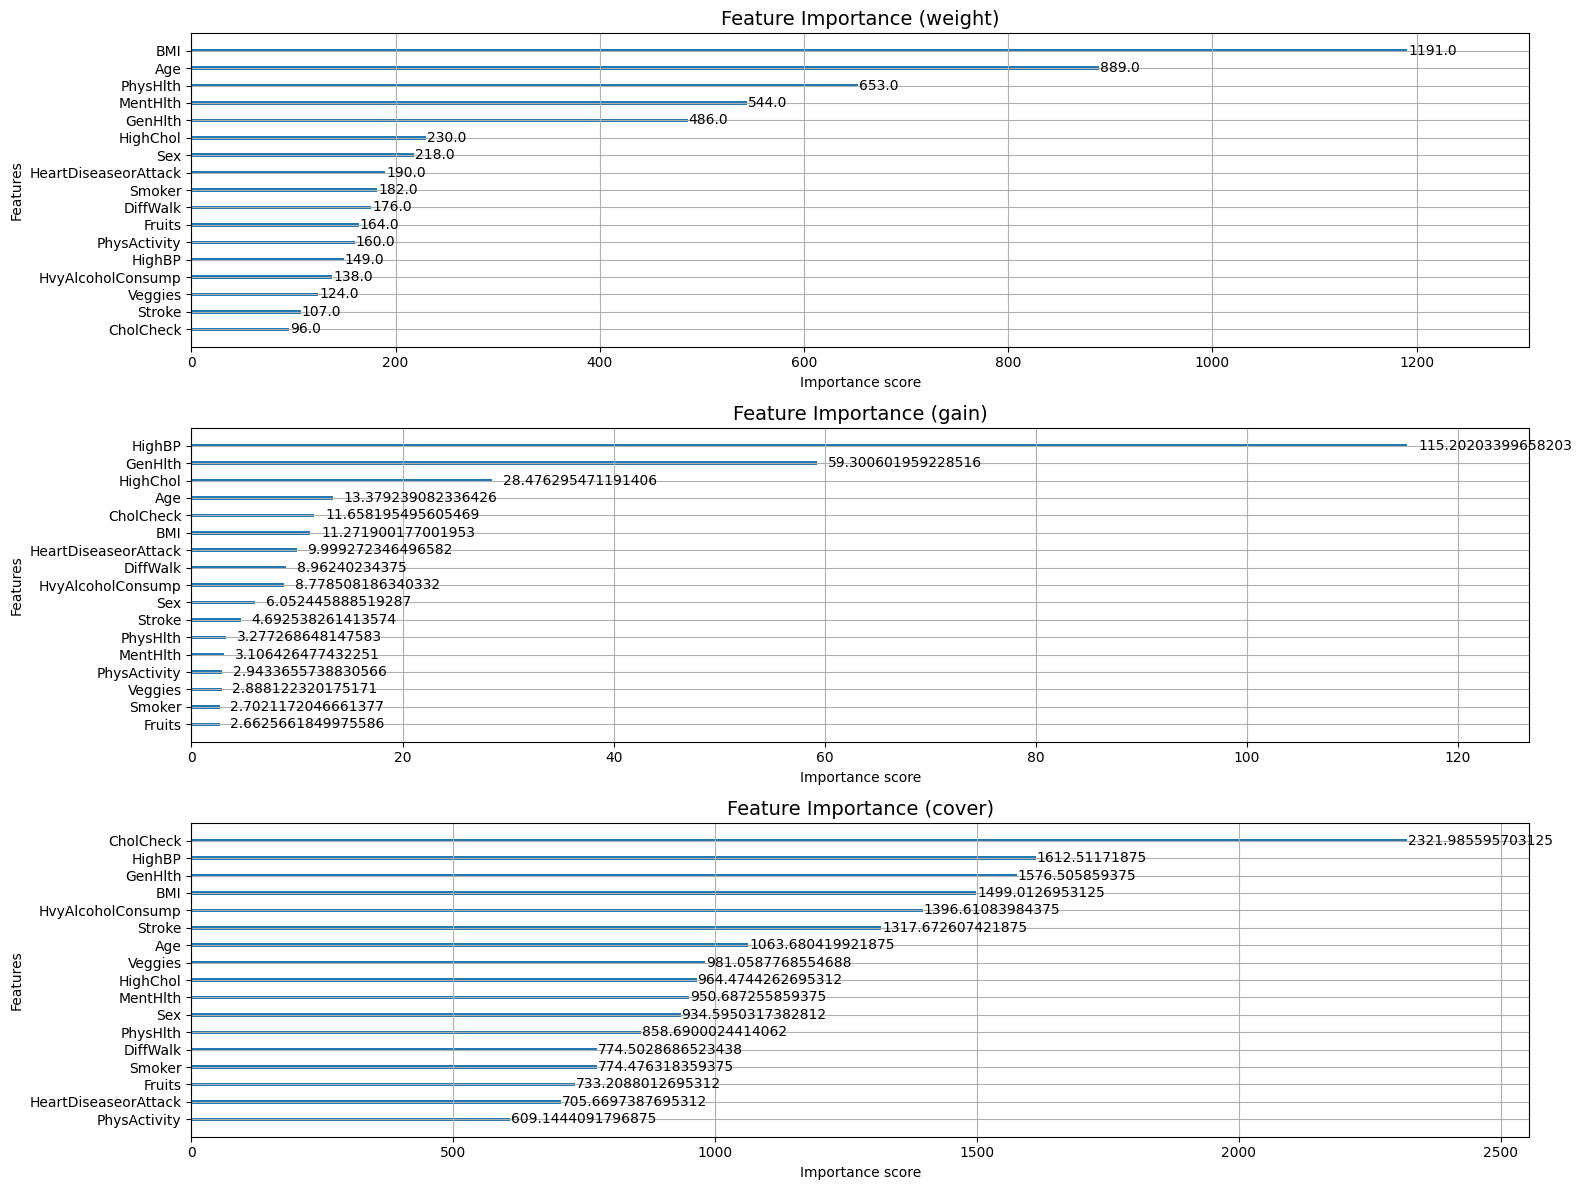

In [4]:
# Inserte su código aquí

import matplotlib.pyplot as plt
from xgboost import plot_importance

# Accedemos al modelo entrenado dentro del pipeline
xgb_model = pipeline.named_steps['classifier']

# Tipos de importancia disponibles en XGBoost:
# - weight: cuántas veces se usó una feature para dividir en los árboles
# - gain: promedio de la ganancia obtenida al usar esa feature
# - cover: promedio de la cobertura (número de observaciones afectadas)

importance_types = ['weight', 'gain', 'cover']

plt.figure(figsize=(16, 12))
for i, imp_type in enumerate(importance_types, 1):
    plt.subplot(3, 1, i)
    plot_importance(xgb_model, importance_type=imp_type, ax=plt.gca())
    plt.title(f"Feature Importance ({imp_type})", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [5]:
# Inserte su código aquí

from sklearn.inspection import permutation_importance

# =========================
# 1. Accedemos al modelo entrenado dentro del pipeline
# =========================
xgb_model = pipeline.named_steps['classifier']

# Obtenemos los nombres de las features después del preprocesamiento
feature_names = xgb_model.get_booster().feature_names
print("Features utilizadas en el modelo:", feature_names)

# =========================
# 2. Importancia por permutación (repetido 30 veces)
# =========================
n_repeats = 30
results = []

for i in range(n_repeats):
    perm = permutation_importance(
        pipeline, X_test, y_test,
        n_repeats=1,  # una permutación por ciclo
        random_state=42 + i,
        scoring='accuracy'
    )
    results.append(perm.importances_mean)

# Convertir a DataFrame
importance_matrix = pd.DataFrame(results, columns=feature_names)

# Promedio y desviación estándar de las importancias
mean_importance = importance_matrix.mean().sort_values(ascending=False)
std_importance = importance_matrix.std().sort_values(ascending=False)

# Combinar resultados
perm_importance_df = pd.DataFrame({
    'Mean Importance': mean_importance,
    'Std Deviation': std_importance
})

print("\n=== Importancia por Permutación (promedio de 30 repeticiones) ===")
print(perm_importance_df.head(10))


Features utilizadas en el modelo: ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Sex', 'HighChol', 'CholCheck', 'Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'DiffWalk', 'Stroke', 'HighBP']

=== Importancia por Permutación (promedio de 30 repeticiones) ===
                      Mean Importance  Std Deviation
Age                          0.028927       0.001371
BMI                          0.025108       0.001778
CholCheck                    0.000430       0.000513
DiffWalk                     0.002333       0.000729
Fruits                       0.052560       0.002264
GenHlth                      0.002563       0.000690
HeartDiseaseorAttack         0.000349       0.000342
HighBP                       0.014565       0.001231
HighChol                     0.002335       0.000724
HvyAlcoholConsump            0.000993       0.000730


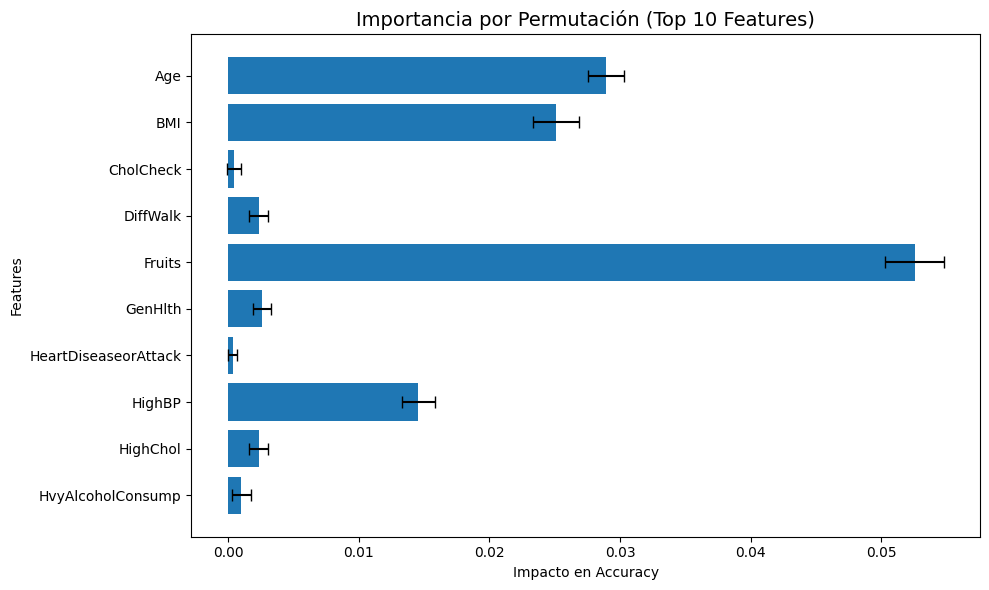

In [6]:
# =========================
# Gráfico con barras y barras de error
# =========================
plt.figure(figsize=(10, 6))
plt.barh(
    y=perm_importance_df.index[:10][::-1],
    width=perm_importance_df['Mean Importance'][:10][::-1],
    xerr=perm_importance_df['Std Deviation'][:10][::-1],
    capsize=4
)
plt.title("Importancia por Permutación (Top 10 Features)", fontsize=14)
plt.xlabel("Impacto en Accuracy")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [7]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [9]:
# Inserte código para calcular shapley values aquí

import shap

# =========================
# Accedemos al modelo XGBoost dentro del pipeline
# =========================
xgb_model = pipeline.named_steps['classifier']

# =========================
# Creamos un objeto explainer
# =========================
# Para XGBoost se recomienda usar TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# =========================
# Calculamos SHAP values para el conjunto de prueba
# =========================
X_test_preprocessed = pipeline.named_steps['preprocessor'].transform(X_test)
shap_values = explainer.shap_values(X_test_preprocessed)

# =========================
# Visualizamos los SHAP values de un paciente específico (ejemplo: primer registro)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_preprocessed.iloc[0,:])


c:\Users\Felipe\Desktop\Lab MDS\lab_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)


--- Paciente 1 ---


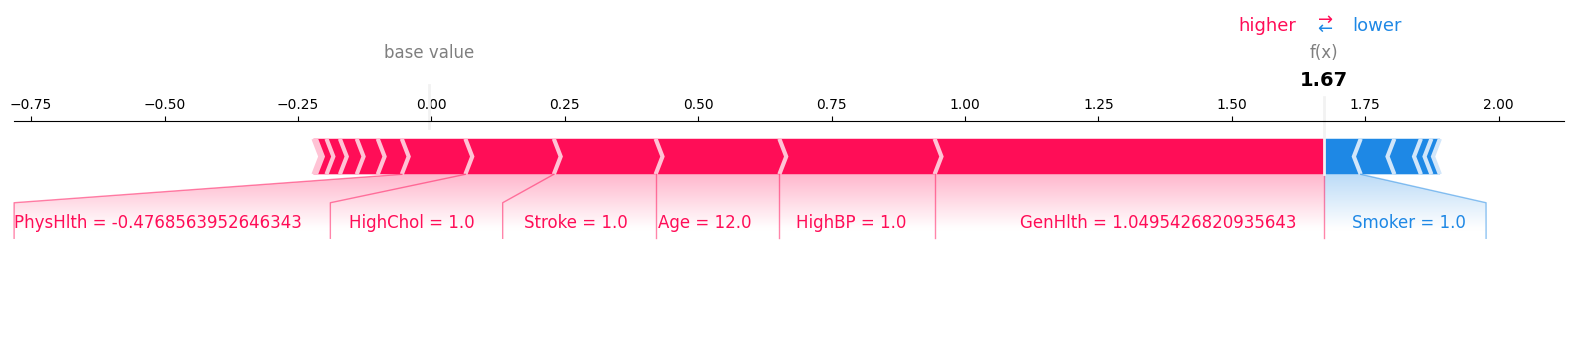


--- Paciente 9 ---


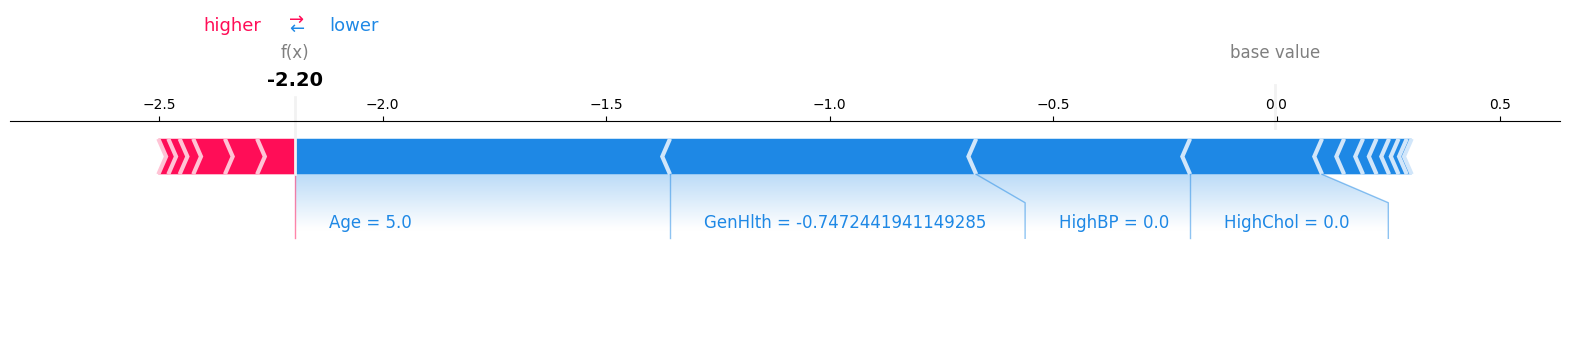


--- Paciente 150 ---


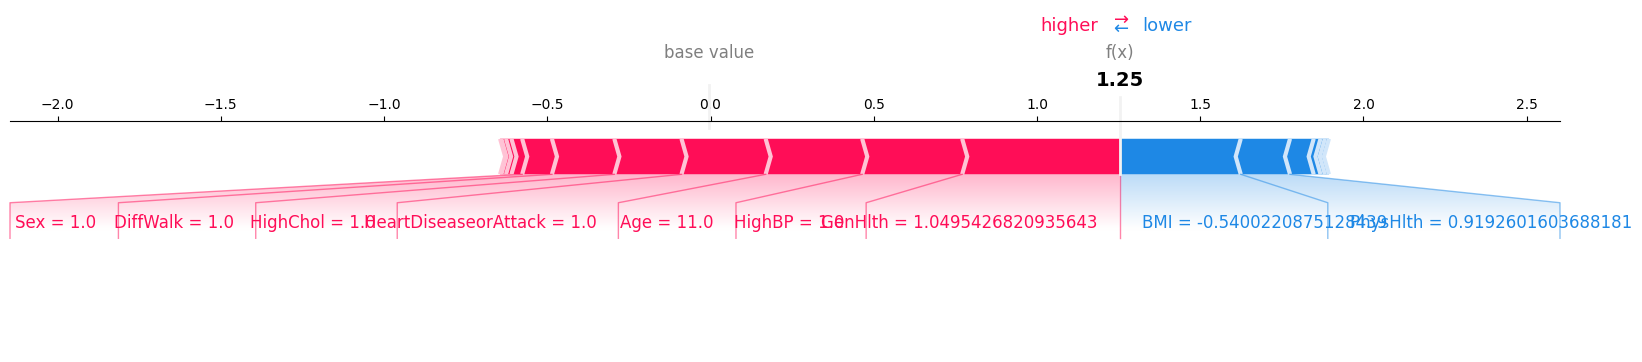

In [10]:
# Inserte código para generar gráficos de aporte local aquí

# Inicializar visualización
shap.initjs()

# Seleccionamos las instancias
instances = [1, 9, 150]

for i in instances:
    print(f"\n--- Paciente {i} ---")
    shap.force_plot(
        explainer.expected_value,
        shap_values[i, :],
        X_test_preprocessed.iloc[i, :],
        matplotlib=True
    )


### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

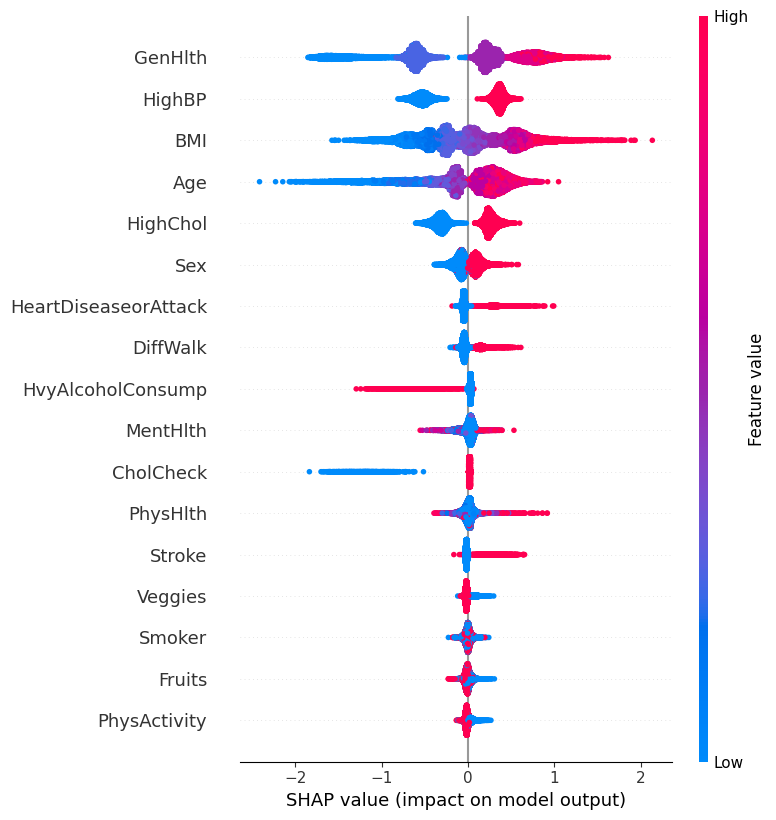

In [11]:
# Inserte código para generar gráficos de aporte global aquí

# Resumen global: muestra distribución de SHAP values por feature
shap.summary_plot(
    shap_values,               # Valores SHAP calculados previamente
    X_test_preprocessed,       # Datos de entrada (preprocesados)
    feature_names=X_test_preprocessed.columns,
    plot_type="dot"            # gráfico tipo "dot" para ver distribución y dirección
)


### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

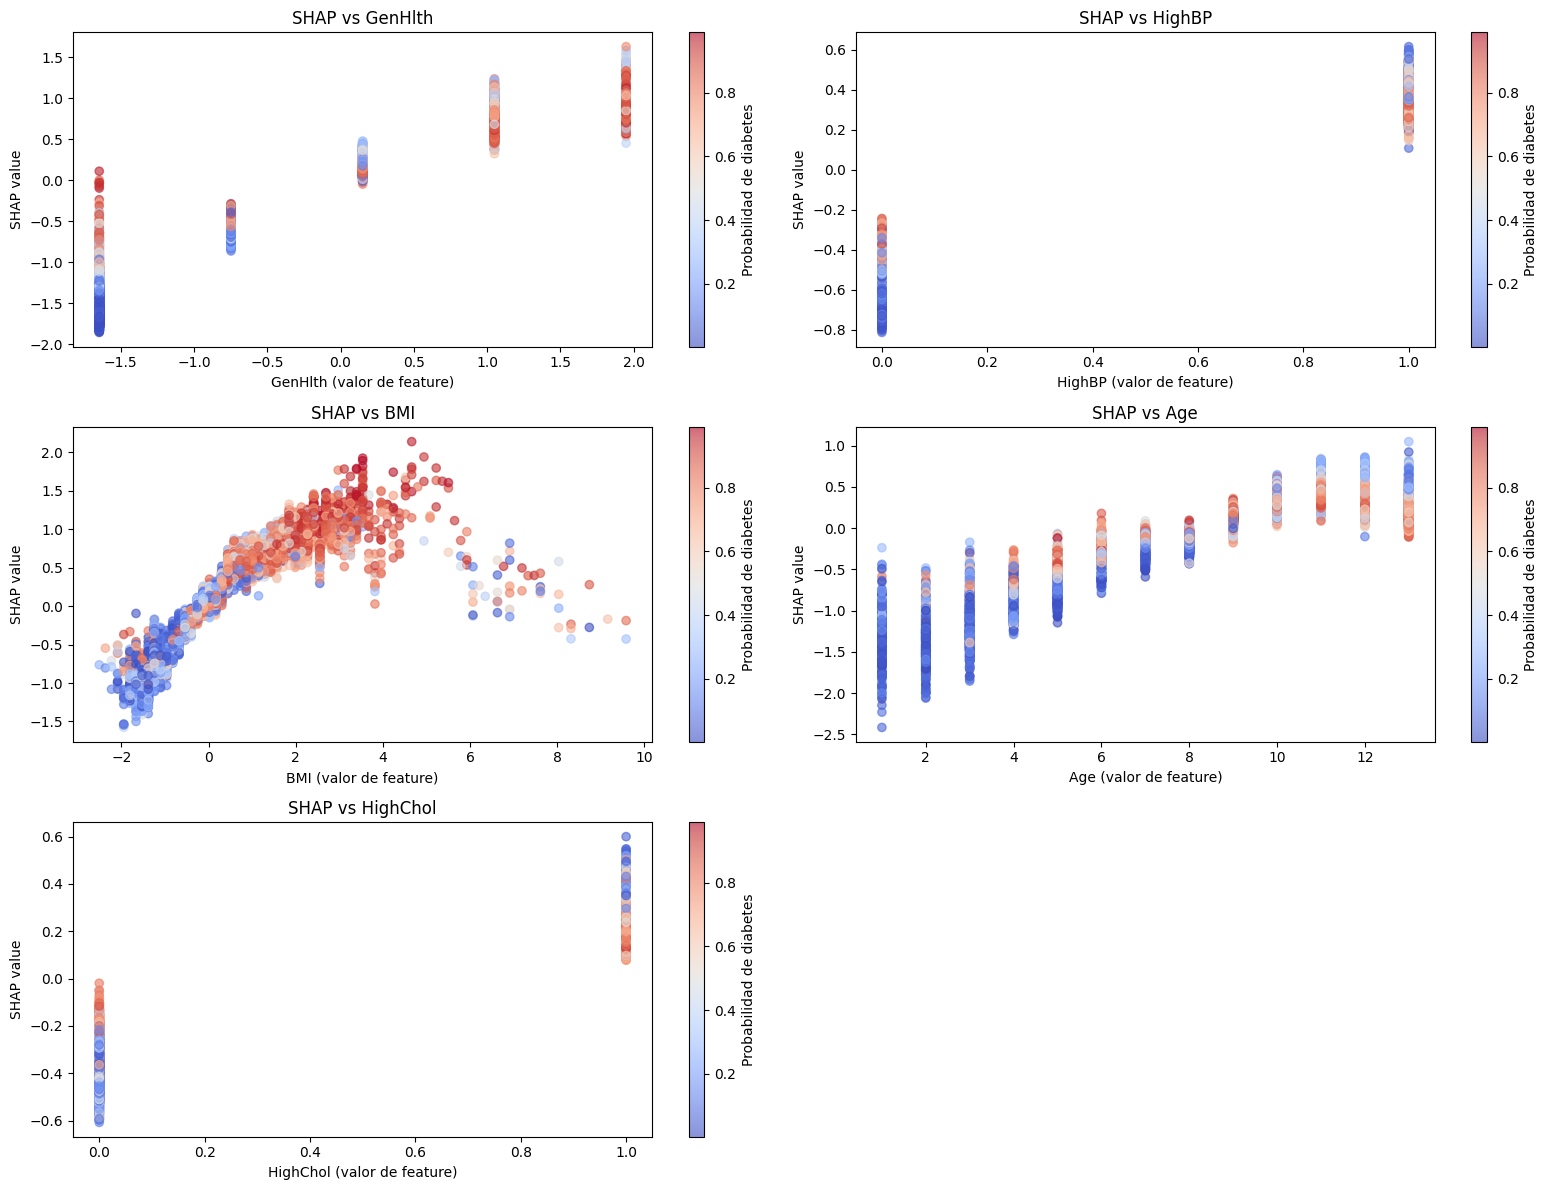

In [12]:
# Inserte código para generar gráficos de feature vs shap value aquí

# Probabilidad predicha de diabetes
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Top 5 features por importancia promedio absoluta
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top5_idx = np.argsort(mean_abs_shap)[-5:][::-1]  # indices de top5 features
top5_features = X_test_preprocessed.columns[top5_idx]

# Scatterplots corregidos
plt.figure(figsize=(16, 12))
for i, idx in enumerate(top5_idx, 1):
    feature = X_test_preprocessed.columns[idx]
    plt.subplot(3, 2, i)
    plt.scatter(
        X_test_preprocessed[feature],
        shap_values[:, idx],  # usar índice en lugar de nombre
        c=y_proba,
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Probabilidad de diabetes')
    plt.xlabel(f'{feature} (valor de feature)')
    plt.ylabel('SHAP value')
    plt.title(f'SHAP vs {feature}')
plt.tight_layout()
plt.show()



### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

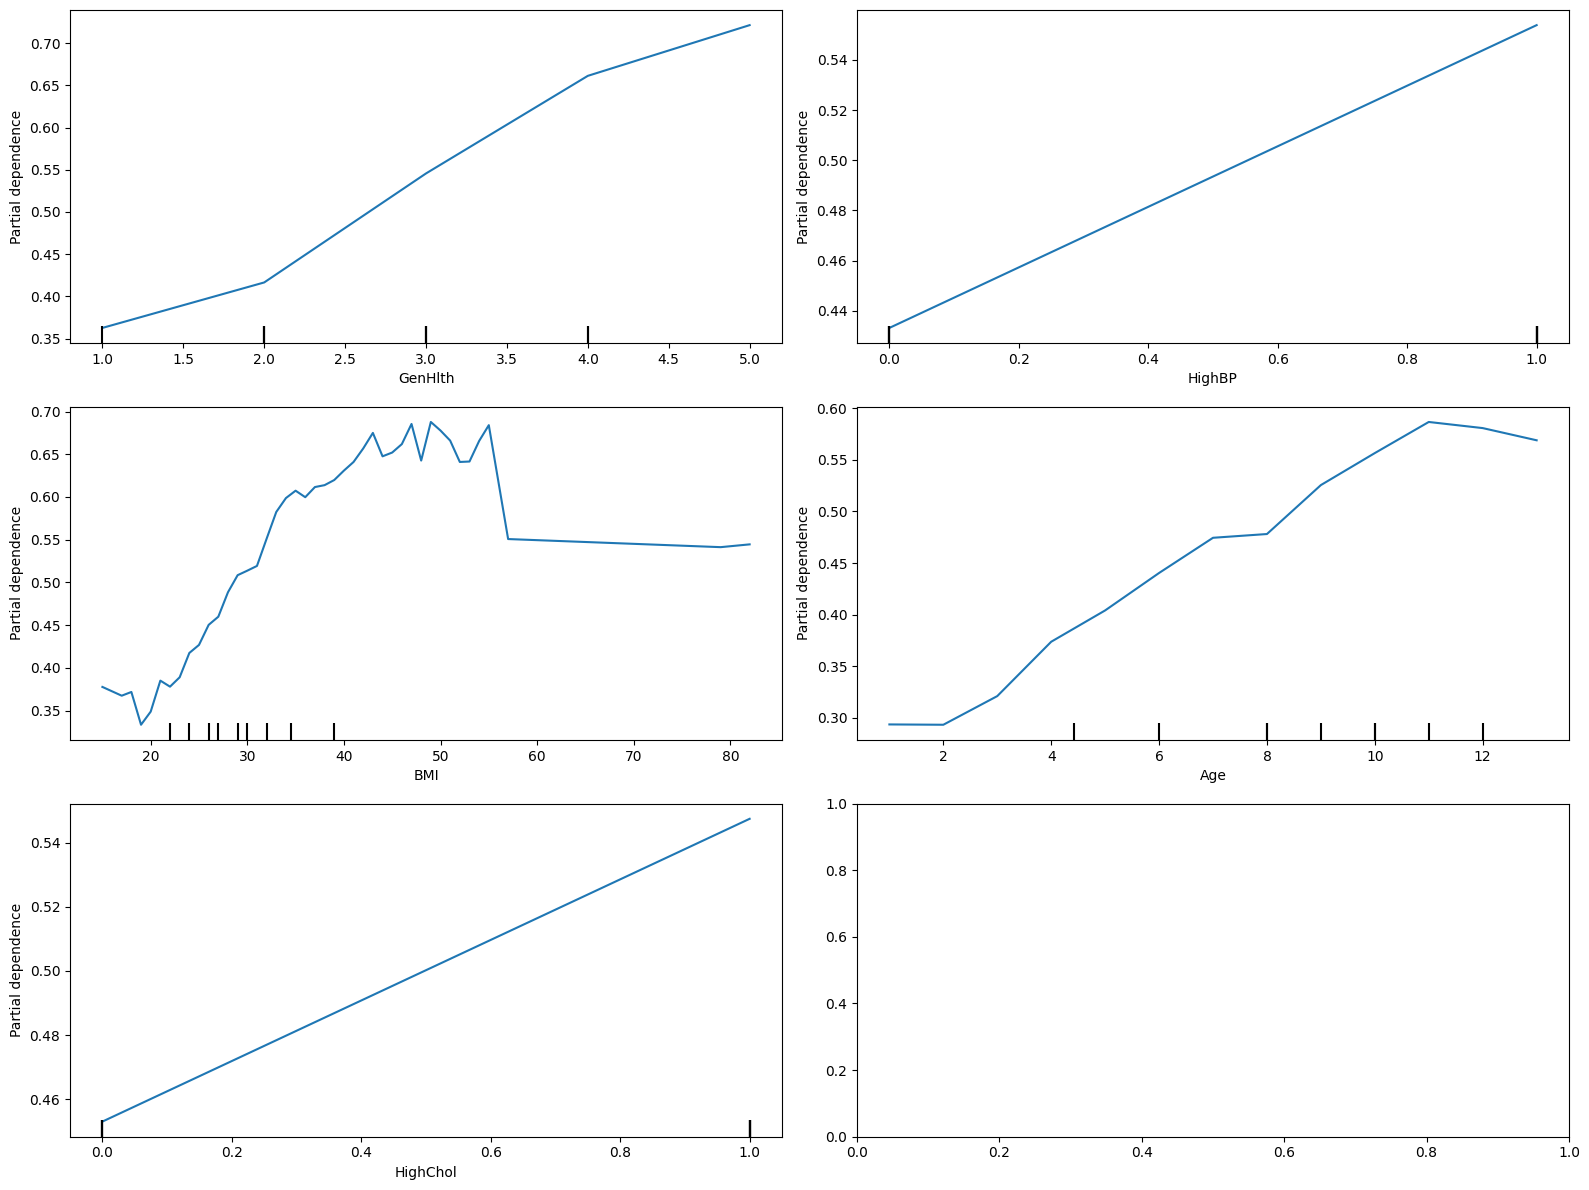

In [13]:
# Inserte código para generar gráficos PDP aquí

from sklearn.inspection import PartialDependenceDisplay

# Tomamos una submuestra de 1000 observaciones para PDP
X_subsample = X_test.sample(n=1000, random_state=42)

# Crear PDP para las 5 features más importantes
top5_features = list(top5_features)  # asegurarnos de que es lista

fig, ax = plt.subplots(3, 2, figsize=(16, 12))
ax = ax.flatten()

for i, feature in enumerate(top5_features):
    PartialDependenceDisplay.from_estimator(
        pipeline, 
        X_subsample, 
        features=[feature], 
        ax=ax[i],
        kind="average"  # promedio del efecto
    )
plt.tight_layout()
plt.show()


## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [26]:
# Inserte su código para generar sistema de reglas aquí

# Preprocesamos el dataset usando el pipeline (solo el preprocesamiento)
X_train_preprocessed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_preprocessed = pipeline.named_steps['preprocessor'].transform(X_test)

# Convertimos a DataFrame para facilidad de manipulación
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=X_test_preprocessed.columns)

top5_features = ['HighBP', 'BMI', 'Age', 'GenHlth', 'PhysActivity']

def rule1(row):
    return int((row['BMI'] > 30) & (row['HighBP'] == 1))

def rule2(row):
    return int((row['Age'] > 55) & (row['PhysActivity'] == 0))

def rule3(row):
    return int((row['BMI'] > 28) & (row['GenHlth'] > 3))


indices = [1000, 3001, 5751]

for idx in indices:
    row = X_test_preprocessed.iloc[idx]
    print(f"\n--- Observación {idx} ---")
    print("Regla 1:", rule1(row))
    print("Regla 2:", rule2(row))
    print("Regla 3:", rule3(row))


--- Observación 1000 ---
Regla 1: 0
Regla 2: 0
Regla 3: 0

--- Observación 3001 ---
Regla 1: 0
Regla 2: 0
Regla 3: 0

--- Observación 5751 ---
Regla 1: 0
Regla 2: 0
Regla 3: 0


In [ ]:
# Cobertura: cuántos pacientes cumplen cada regla
coverage_rule1 = X_test_preprocessed.apply(rule1, axis=1).sum() / len(X_test_preprocessed)
coverage_rule2 = X_test_preprocessed.apply(rule2, axis=1).sum() / len(X_test_preprocessed)
coverage_rule3 = X_test_preprocessed.apply(rule3, axis=1).sum() / len(X_test_preprocessed)

# Precisión: proporción de predicciones correctas según la variable objetivo y_test
precision_rule1 = (y_test.values == X_test_preprocessed.apply(lambda row: rule1(row), axis=1)).mean()
precision_rule2 = (y_test.values == X_test_preprocessed.apply(lambda row: rule2(row), axis=1)).mean()
precision_rule3 = (y_test.values == X_test_preprocessed.apply(lambda row: rule3(row), axis=1)).mean()

print("\nCobertura y precisión de las reglas:")
print(f"Regla 1 -> Cobertura: {coverage_rule1:.2f}, Precisión: {precision_rule1:.2f}")
print(f"Regla 2 -> Cobertura: {coverage_rule2:.2f}, Precisión: {precision_rule2:.2f}")
print(f"Regla 3 -> Cobertura: {coverage_rule3:.2f}, Precisión: {precision_rule3:.2f}")



Cobertura y precisión de las reglas:
Regla 1 -> Cobertura: 0.00, Precisión: 0.50
Regla 2 -> Cobertura: 0.00, Precisión: 0.50
Regla 3 -> Cobertura: 0.00, Precisión: 0.50


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>